# Stochastic evolution of a colony of B cells

In [66]:
import matplotlib.pyplot as plt
from __future__ import annotations
import numpy as np
from numpy.random import default_rng

In [171]:
"""
Germinal‑centre B‑cell maturation with multiple antigens
========================================================

• State of each cycling B‑cell: h ∈ ℝ^{N_h} (residue binding‑energy vector)
• Antigens:            S_mat ∈ {‑1, +1}^{N_h × n_A}
                       ε_v(h) = Σ_i s_{iv} h_i    for every antigen v
• One round:           duplication → SHM → Ag‑gate → T‑gate → differentiation
• Output:              `history[step]` is a NumPy array of shape
                       (n_cells_alive_that_step, N_h) with the h‑vectors

The implementation below follows exactly the gates used in your FP solver.
"""


# p_sil=(1-0.001)**200# 0.8   , 0.7, 0.72, 0.85
# p_let=0.5*(1-p_sil)
# p_aa=0.5*(1-p_sil)
mu=0.001*3*220
p_sil=0.5*(mu)+(1-mu)
p_let=0.3*(mu)
p_aa=0.2*(mu)
E_a=np.log(40)                       
T=140
kBT=1                       # thermal factor
N_i=2500  
N_max=2500 
mu_i=0.0 
sigma_i=0.005
p_diff=0.10
c=600# 800, 1120, 920, 510

# global parameters (use existing values or define defaults)

# -------------------------- helper functions ---------------------------
def energies(pop: np.ndarray, S_mat: np.ndarray) -> np.ndarray:
    """
    Compute energies for every cell and every antigen.

    Parameters
    ----------
    pop   : (N_cells, N_h) ndarray
    S_mat : (N_h, n_A)     ndarray

    Returns
    -------
    eps : (N_cells, n_A) ndarray   with eps[c, v] = ε_v(h_c)
    """
    return pop @ S_mat                     # broadcasting handles dot‑product

def P_Ag(eps: np.ndarray, C_vec: np.ndarray) -> np.ndarray:
    """
    Antigen‑binding survival gate   P_Ag(h)

    eps   : (N_cells, n_A) energies
    C_vec : (n_A,)        antigen concentrations at current round
    """
    exp_term   = np.exp((eps - E_a) / kBT)         # same as FP code
    numer      = (exp_term * C_vec).sum(axis=1)    # Σ_v C_v e^{(ε_v - E_a)/kT}
    return numer / (1.0 + numer)

def P_T(eps: np.ndarray, C_vec: np.ndarray) -> np.ndarray:
    """
    T‑cell‑help survival gate   P_T(h | pop)

    eps   : (N_cells, n_A) energies *after* Ag selection
    """
    C_tot      = C_vec.sum()
    eE         = np.exp(eps / kBT)                 # e^{ε_v/kT}
    Phi        = (eE * C_vec).sum(axis=1)          # Σ_v C_v e^{ε_v/kT}
    Phi_bar    = Phi.mean()                       # ⟨Φ⟩_pop
    return Phi / (Phi + Phi_bar / C_tot)

# --

## Trying to track mutations

In [172]:
def gc_round(pop: np.ndarray,
             S_mat: np.ndarray,
             C_vec: np.ndarray,
             rng: np.random.Generator,
             mu_M: np.ndarray,
             sigma_M: np.ndarray,
             mutable_positions=None,
             uniq_counts: np.ndarray | None = None,        # NEW: unique mutated sites per cell
             mut_sites: np.ndarray | None = None           # NEW: boolean mask (n_cells, N_h)
             ) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Returns:
        pop_next   : GC survivors after differentiation (n_t, N_h)
        mem_cells  : differentiated cells (n_mem, N_h)
        parent_idx : parent row index in previous gen (n_t,)
        uniq_counts: unique mutated-site counts aligned to pop_next (n_t,)
        mut_sites  : boolean mutated-sites mask aligned to pop_next (n_t, N_h)
    Counting rule: only the first mutation at a site counts for that lineage; repeated hits to the same site do not.
    """
    N_h = pop.shape[1]
    assert mu_M.shape == (N_h,) and sigma_M.shape == (N_h,), "mu_M and sigma_M must be length N_h"

    # init counters/masks for gen-0
    if uniq_counts is None:
        uniq_counts = np.zeros(pop.shape[0], dtype=int)
    if mut_sites is None:
        mut_sites = np.zeros((pop.shape[0], N_h), dtype=bool)

    # 1) Duplication: replicate state, counts, and masks; track parents
    prev_n = pop.shape[0]
    pop        = np.repeat(pop,        2, axis=0)
    uniq_counts = np.repeat(uniq_counts, 2, axis=0)
    mut_sites  = np.repeat(mut_sites,  2, axis=0)
    parent_idx = np.repeat(np.arange(prev_n, dtype=int), 2)


    # 2) SHM: at most one site per mutating cell this round
    N_cells = pop.shape[0]
    fate = rng.choice(["let", "aa", "sil"], size=N_cells, p=[p_let, p_aa, p_sil])
    alive_mask = fate != "let"
    aa_mask    = fate == "aa"

    if aa_mask.any():
        rows = np.flatnonzero(aa_mask)
        if mutable_positions is None:
            idx_sites = rng.integers(0, N_h, size=rows.size)
        else:
            mp = np.asarray(mutable_positions, dtype=int)
            idx_sites = rng.choice(mp, size=rows.size)
        delta_h = rng.normal(mu_M[idx_sites], sigma_M[idx_sites])
        # apply mutation to h
        pop[rows, idx_sites] = np.clip(pop[rows, idx_sites] + delta_h, -6, 2)

        # UNIQUE-SITE counting: only first hit to a site increments
        # (relative to this lineage's gen-0 founder; we encode that by the boolean mut_sites)
        for r, i in zip(rows, idx_sites):
            if not mut_sites[r, i]:
                uniq_counts[r] += 1
                mut_sites[r, i] = True

    # lethal removal
    pop        = pop[alive_mask]
    parent_idx = parent_idx[alive_mask]
    uniq_counts = uniq_counts[alive_mask]
    mut_sites  = mut_sites[alive_mask]
    if pop.size == 0:
        return pop, np.empty((0, N_h)), np.empty((0,), dtype=int), np.empty((0,), dtype=int), np.empty((0, N_h), dtype=bool)

    # 3) Antigen-binding gate (shape-safe reduction over possible multi-C_vec outputs)
    eps  = energies(pop, S_mat)
    P_ag = P_Ag(eps, C_vec)
    if isinstance(P_ag, np.ndarray) and P_ag.ndim == 2:
        P_ag = P_ag.max(axis=1)  # or .mean/.min per your policy
    P_ag = np.asarray(P_ag, dtype=float).reshape(-1)
    assert P_ag.shape[0] == pop.shape[0]
    survive = rng.random(pop.shape[0]) < P_ag

    pop        = pop[survive]
    parent_idx = parent_idx[survive]
    uniq_counts = uniq_counts[survive]
    mut_sites  = mut_sites[survive]
    if pop.size == 0:
        return pop, np.empty((0, N_h)), np.empty((0,), dtype=int), np.empty((0,), dtype=int), np.empty((0, N_h), dtype=bool)

    # 4) T-cell-help gate (shape-safe)
    P_t = P_T(eps, C_vec)
    if isinstance(P_t, np.ndarray) and P_t.shape[0] != pop.shape[0]:
        eps_t = energies(pop, S_mat)
        P_t = P_T(eps_t, C_vec)
    if isinstance(P_t, np.ndarray) and P_t.ndim == 2:
        P_t = P_t.max(axis=1)
    P_t = np.asarray(P_t, dtype=float).reshape(-1)
    if P_t.shape[0] != pop.shape[0]:
        if P_t.size == 1:
            P_t = np.full(pop.shape[0], float(P_t))
        else:
            raise ValueError(f"P_T shape {P_t.shape} must match n_cells {pop.shape[0]}")
    survive = rng.random(pop.shape[0]) < P_t

    pop        = pop[survive]
    parent_idx = parent_idx[survive]
    uniq_counts = uniq_counts[survive]
    mut_sites  = mut_sites[survive]
    if pop.size == 0:
        return pop, np.empty((0, N_h)), np.empty((0,), dtype=int), np.empty((0,), dtype=int), np.empty((0, N_h), dtype=bool)

    # 5) Differentiation
    diff_mask  = rng.random(size=pop.shape[0]) < p_diff
    mem_cells  = pop[diff_mask]
    keep_mask  = ~diff_mask
    pop        = pop[keep_mask]
    parent_idx = parent_idx[keep_mask]
    uniq_counts = uniq_counts[keep_mask]
    mut_sites  = mut_sites[keep_mask]

    return pop, mem_cells, parent_idx, uniq_counts, mut_sites


In [173]:
def plot_h_dimension(history, dim_idx=0, h_min=-4, h_max=10, n_hbins=100, t_clip=50, cmap="Greys_r"):
    """
    Plot the density of B-cell h[dim_idx] values over rounds with fixed colorbar scale [0, 500].
    """
    time_points = []
    h_values = []
    for t, pop in enumerate(history):
        if pop.size == 0:
            continue
        time_points.extend([t] * pop.shape[0])
        h_values.extend(pop[:, dim_idx])

    rounds_arr = np.asarray(time_points)
    h_vals     = np.asarray(h_values)

    n_rounds   = len(history)
    round_bins = np.linspace(rounds_arr.min(), rounds_arr.max(), n_rounds + 1)
    h_bins     = np.linspace(h_min, h_max, n_hbins + 1)

    H, xedges, yedges = np.histogram2d(rounds_arr, h_vals, bins=[round_bins, h_bins])

    plt.figure(figsize=(8, 5))
    im = plt.imshow(H.T, origin="lower", aspect="auto",
                    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
                    cmap=cmap, vmin=0.0, vmax=100)  # fixed scale
    plt.xlabel("Round")
    plt.ylabel(rf"$h_{{{dim_idx+1}}}$")
    plt.title(rf"Density of B-cells in $h_{{{dim_idx+1}}}$ over GC rounds")
    plt.colorbar(im, label="Density")
    plt.ylim(h_min, h_max)
    plt.tight_layout()
    plt.show()

# Example

def simulate_gc_history(rounds: int,
                        S_mat: np.ndarray,
                        N_init: int = N_i,
                        N_max: int  = N_max,
                        C_schedule = lambda: np.array([c]),
                        mu_init: float = mu_i,
                        sigma_init: float = sigma_i,
                        mu_M: np.ndarray | None = None,
                        sigma_M: np.ndarray | None = None,
                        mutable_positions=None,
                        seed: int | None = None
                        ) -> tuple[list[np.ndarray], list[np.ndarray], list[np.ndarray]]:
    """
    Returns:
        history         : list of cell states per generation (t=0..T)
        parent_links    : list where parent_links[t] maps rows of history[t] -> indices in history[t-1]
        uniq_counts_hist: list of int arrays (unique mutated-site count) aligned to history[t]
    """
    rng = default_rng(seed)
    N_h = S_mat.shape[0]
    if mu_M is None or sigma_M is None:
        raise ValueError("Provide per-site mu_M and sigma_M of shape (N_h,)")

    pop = rng.normal(mu_init, sigma_init, size=(N_init, N_h))
    if mutable_positions is not None:
        mutable_positions = np.array(mutable_positions, dtype=int)
        all_positions = np.arange(N_h)
        non_mutable_positions = np.setdiff1d(all_positions, mutable_positions)
        pop[:, non_mutable_positions] = 0.0

    history = [pop.copy()]
    parent_links: list[np.ndarray | None] = [None]
    uniq_counts_hist = [np.zeros(pop.shape[0], dtype=int)]

    # working state carried across rounds
    uniq_counts = uniq_counts_hist[0].copy()
    mut_sites   = np.zeros((pop.shape[0], N_h), dtype=bool)

    for _ in range(rounds):
        C_vec = np.asarray(C_schedule(), dtype=float)
        pop_next, _mem, parent_idx, uniq_counts, mut_sites = gc_round(
            pop, S_mat, C_vec, rng, mu_M, sigma_M,
            mutable_positions=mutable_positions,
            uniq_counts=uniq_counts, mut_sites=mut_sites
        )

        # apply cap consistently
        if pop_next.shape[0] > N_max:
            keep_idx   = rng.choice(pop_next.shape[0], N_max, replace=False)
            pop_next   = pop_next[keep_idx]
            parent_idx = parent_idx[keep_idx]
            uniq_counts = uniq_counts[keep_idx]
            mut_sites   = mut_sites[keep_idx]

        history.append(pop_next.copy())
        parent_links.append(parent_idx.copy())
        uniq_counts_hist.append(uniq_counts.copy())
        pop = pop_next

    return history, parent_links, uniq_counts_hist



len 233
EVQLQESGPSLVKPSQTLSLTCSVTGDSITSGYWNWIRKFPGNKLEYMGYISYSGSTYYNPSLKSRISITRDTSKNQYYLQLNSVTTEDTATYYCARDFDVWGAGTTVTVSSGGGGSGGGSGGGSDIVMTQSQKFMSTSVGDRVSVTCKASQNVGTNVAWYQQKPGQSPKALIYSASYRYSGVPDRFTGSGSGTDFTLTISNVQSEDLAEYFCQQYNSYPLTFGSGTKLEIKR
220
[ 3.44696988e-01  2.14600931e-02  1.05448529e-01  2.44465459e-01
  1.36697898e-01  1.91374426e-01  7.82832880e-02  1.06987314e-01
  2.14528564e-01  5.77126507e-02  6.33112218e-02  7.46766722e-02
  4.83246823e-02  1.65940729e-01  2.00143986e-01  8.88896528e-02
  3.54022458e-02 -4.22493663e-01  2.51343610e-02 -3.87130342e-01
 -1.65847529e-01 -1.62481917e+00 -1.52542973e-01 -9.89397789e-01
 -3.27772988e-02  2.21031722e-01  1.26389759e+00  1.69601839e-01
 -7.12051414e-01 -3.07314519e-01 -5.29462995e-02 -1.51018662e+00
 -3.14495296e+00 -3.03717882e+00 -1.78031850e+00 -4.05941914e-01
 -1.55210929e+00 -1.48396620e+00 -2.67751173e-01  1.03122918e-01
  1.60542811e-01 -6.78188063e-02 -2.03315385e-01 -7.28505029e-02
  2.97987405e-02  4.98575461e-02 -3.003

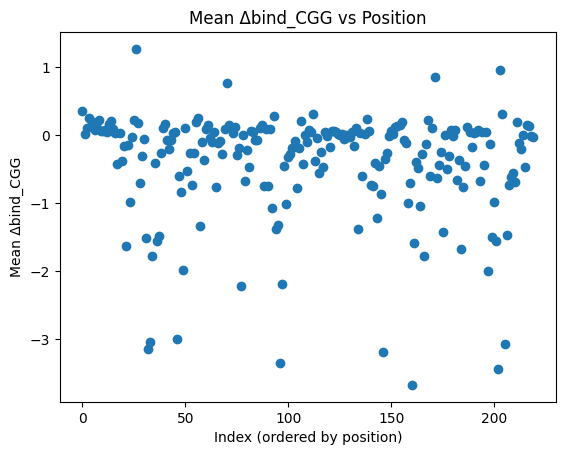

In [174]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data_mat/final_variant_scores.csv')
# Group by position, take the first wildtype amino acid for each position
wt_seq = (
    df.groupby("position")["wildtype"]
      .first()
      .sort_index()
      .str.cat()
)
print('len',len(wt_seq))

print(wt_seq)

df = df[df["single_nt"].apply(lambda x: isinstance(x, bool))]
df = df[df["single_nt"]]  # keep only single-nt rows
df['position'] = df['position'] - 1

# Group and compute mean/std
stats = df.groupby(["position", "annotation"])["delta_bind_CGG"].agg(["mean", "std"]).reset_index()

# Arrays (ordered by position)
positions = stats["position"].to_numpy()
mu_arr = stats["mean"].to_numpy() * np.log(10)
sigma_arr = stats["std"].to_numpy() * np.log(10)

print(len(positions))
print(mu_arr)
print(sigma_arr)

# Save CSV
stats_out = stats.copy()
stats_out["mean"] = stats_out["mean"] * np.log(10)
stats_out["std"] = stats_out["std"] * np.log(10)
# stats_out.to_csv("annotation_position_mean_std.csv", index=False)

# Plot
plt.scatter(np.arange(len(mu_arr)), mu_arr)
plt.xlabel("Index (ordered by position)")
plt.ylabel("Mean Δbind_CGG")
plt.title("Mean Δbind_CGG vs Position")
plt.show()


In [175]:
print(df.annotation.unique())
# Keep only unique (position, annotation) pairs
pos_annotation_dict = (
    df.drop_duplicates(subset=["position", "annotation"])
      .set_index("position")["annotation"]
      .to_dict()
)

print(pos_annotation_dict)
cdr_positions = (
    df[df["annotation"].str.contains("CDR", na=False)]
    .drop_duplicates(subset=["position"])
    [["position"]]
    .to_records(index=False)
    .tolist()
)
cdr_positions=[pos[0] for pos in cdr_positions]
print(cdr_positions)#absolute position
#i need index of cdr_positions inside position array
cdr_positions_relative = [np.where(positions == p)[0][0] for p in cdr_positions]

print(cdr_positions_relative)

['FWRH1' 'CDRH1' 'FWRH2' 'CDRH2' 'FWRH3' 'CDRH3' 'FWRH4' 'FWRL1' 'CDRL1'
 'FWRL2' 'CDRL2' 'FWRL3' 'CDRL3' 'FWRL4']
{0: 'FWRH1', 1: 'FWRH1', 2: 'FWRH1', 3: 'FWRH1', 4: 'FWRH1', 5: 'FWRH1', 6: 'FWRH1', 7: 'FWRH1', 8: 'FWRH1', 9: 'FWRH1', 10: 'FWRH1', 11: 'FWRH1', 12: 'FWRH1', 13: 'FWRH1', 14: 'FWRH1', 15: 'FWRH1', 16: 'FWRH1', 17: 'FWRH1', 18: 'FWRH1', 19: 'FWRH1', 20: 'FWRH1', 21: 'FWRH1', 22: 'FWRH1', 23: 'FWRH1', 24: 'FWRH1', 25: 'CDRH1', 26: 'CDRH1', 27: 'CDRH1', 28: 'CDRH1', 29: 'CDRH1', 30: 'CDRH1', 31: 'CDRH1', 32: 'CDRH1', 33: 'FWRH2', 34: 'FWRH2', 35: 'FWRH2', 36: 'FWRH2', 37: 'FWRH2', 38: 'FWRH2', 39: 'FWRH2', 40: 'FWRH2', 41: 'FWRH2', 42: 'FWRH2', 43: 'FWRH2', 44: 'FWRH2', 45: 'FWRH2', 46: 'FWRH2', 47: 'FWRH2', 48: 'FWRH2', 49: 'CDRH2', 50: 'CDRH2', 51: 'CDRH2', 52: 'CDRH2', 53: 'CDRH2', 54: 'CDRH2', 55: 'CDRH2', 56: 'CDRH2', 57: 'FWRH3', 58: 'FWRH3', 59: 'FWRH3', 60: 'FWRH3', 61: 'FWRH3', 62: 'FWRH3', 63: 'FWRH3', 64: 'FWRH3', 65: 'FWRH3', 66: 'FWRH3', 67: 'FWRH3', 68: 'FWRH3

In [176]:
len(mu_arr)

220

In [177]:

# Turn your scalar params into per-site vectors (or set site-specific values here)
S_mat = np.array([[1] for pos in range (len(positions))])

N_h   = S_mat.shape[0]
print('Nh', N_h)
# Antigen concentration (constant here)
def C_schedule():
    return np.array([c])

history,parent_links, uniq_counts_hist  = simulate_gc_history(
    rounds      = T,
    S_mat       = S_mat,
    N_init      = N_i,
    N_max       = N_max,
    C_schedule  = C_schedule,
    mu_M        = mu_arr,
    sigma_M     = sigma_arr,
    mutable_positions=cdr_positions_relative,
    seed        = 42
)

print(f"Rounds simulated: {len(history)-1}")
for t, pop in enumerate(history):
    print(f"t={t:02d}  cycling cells={pop.shape[0]}")


Nh 220
Rounds simulated: 140
t=00  cycling cells=2500
t=01  cycling cells=2500
t=02  cycling cells=2500
t=03  cycling cells=2500
t=04  cycling cells=2500
t=05  cycling cells=2500
t=06  cycling cells=2500
t=07  cycling cells=2500
t=08  cycling cells=2500
t=09  cycling cells=2500
t=10  cycling cells=2500
t=11  cycling cells=2500
t=12  cycling cells=2500
t=13  cycling cells=2500
t=14  cycling cells=2500
t=15  cycling cells=2500
t=16  cycling cells=2500
t=17  cycling cells=2500
t=18  cycling cells=2500
t=19  cycling cells=2500
t=20  cycling cells=2500
t=21  cycling cells=2500
t=22  cycling cells=2500
t=23  cycling cells=2500
t=24  cycling cells=2500
t=25  cycling cells=2500
t=26  cycling cells=2500
t=27  cycling cells=2500
t=28  cycling cells=2500
t=29  cycling cells=2500
t=30  cycling cells=2500
t=31  cycling cells=2500
t=32  cycling cells=2500
t=33  cycling cells=2500
t=34  cycling cells=2500
t=35  cycling cells=2500
t=36  cycling cells=2500
t=37  cycling cells=2500
t=38  cycling cells=2

mean_exp [-0.12944443 -0.37343535  0.50442515  1.31840739  2.11250799  2.29889219
  6.60429562]
times_exp [ 10.  16.  22.  28.  34.  40. 140.]


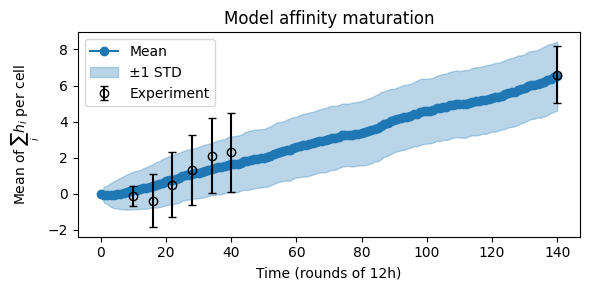

In [178]:
import numpy as np
import matplotlib.pyplot as plt

# history is a list of arrays: one array per time point, shape (n_cells_t, N_h)
df_mat = (pd.read_csv("../data_mat/data.csv", keep_default_na=False)
        [["time (days)", "delta_bind_CGG"]]
        .rename(columns={"time (days)": "t", "delta_bind_CGG": "x"}))

df_mat["t"] = df_mat["t"] * 2.0            # days  →  12 h
df_mat["x"] = df_mat["x"] * np.log(10.0)   # log scale

times_exp = np.sort(df_mat.t.unique())
mean_exp  = (df_mat.groupby("t")["x"]
               .mean()
               .reindex(times_exp)
               .values)

print("mean_exp", mean_exp)
print("times_exp", times_exp)  # in 12 h
exp_mean  = mean_exp
exp_std   = (df_mat.groupby("t")["x"].std()
               .reindex(times_exp)
               .fillna(0.0)          # if only one replica at a time point
               .values)

mean_sum_hi_per_time = []
std_sum_hi_per_time = []

for pop in history:
    if pop.size == 0:
        mean_sum_hi_per_time.append(np.nan)
        std_sum_hi_per_time.append(np.nan)
    else:
        sum_hi_per_cell = pop.sum(axis=1)  # sum over h_i for each cell
        mean_sum_hi_per_time.append(sum_hi_per_cell.mean())
        std_sum_hi_per_time.append(sum_hi_per_cell.std())

times = np.arange(len(history))
mean_sum_hi_per_time = np.array(mean_sum_hi_per_time)
std_sum_hi_per_time = np.array(std_sum_hi_per_time)

plt.figure(figsize=(6, 3))
plt.plot(times, mean_sum_hi_per_time, marker='o', color='C0', label="Mean")
plt.fill_between(
    times,
    mean_sum_hi_per_time - std_sum_hi_per_time,
    mean_sum_hi_per_time + std_sum_hi_per_time,
    color='C0',
    alpha=0.3,
    label="±1 STD"
)
plt.errorbar(times_exp, exp_mean, yerr=exp_std,
             fmt='o', mfc='none', ecolor='k', color='k',
             capsize=3, label='Experiment')
plt.xlabel("Time (rounds of 12h)")
plt.ylabel(r"Mean of $\sum_i h_i$ per cell")
plt.title("Model affinity maturation")
plt.legend()
plt.tight_layout()
plt.show()


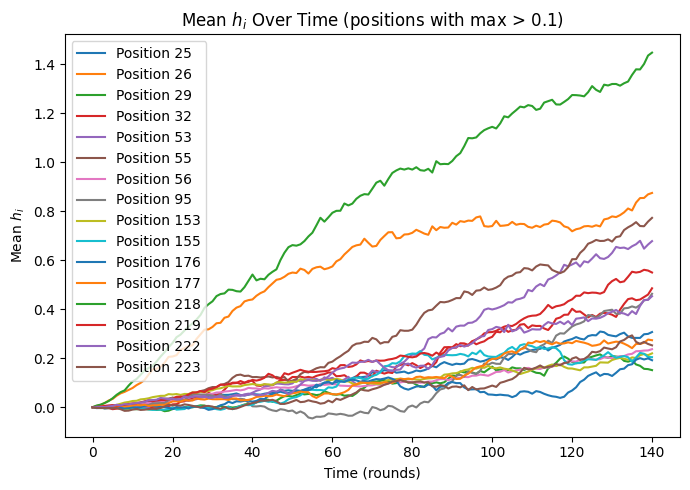

In [179]:
import numpy as np
import matplotlib.pyplot as plt

# Determine N_h from first timepoint
N_h = history[0].shape[1]

# Compute mean h_i per time for each position
mean_hi_per_time = np.zeros((len(history), N_h))

for t, pop in enumerate(history):
    if pop.size == 0:
        mean_hi_per_time[t, :] = np.nan
    else:
        mean_hi_per_time[t, :] = pop.mean(axis=0)

# Filter positions with max value > 0.1
mask = (np.nanmax(mean_hi_per_time, axis=0) > 0.2)
selected_positions = np.where(mask)[0]

# Plot each selected position
plt.figure(figsize=(7, 5))
for i in selected_positions:
    plt.plot(np.arange(len(history)), mean_hi_per_time[:, i], label=f"Position {positions[i]}")

plt.xlabel("Time (rounds)")
plt.ylabel(r"Mean $h_i$")
plt.title("Mean $h_i$ Over Time (positions with max > 0.1)")
plt.legend()
plt.tight_layout()
plt.show()


In [180]:
import pandas as pd

# Times of interest
times_of_interest = np.array([5, 8, 11, 14, 17, 20, 70])*2

# Build a DataFrame
records = []
for i in range(N_h):
    for t in times_of_interest:
        if t < len(history):  # avoid out-of-bounds
            records.append({
                "position": positions[i],
                "time": t,
                "mean_hi": mean_hi_per_time[t, i]
            })

df_out = pd.DataFrame(records)

# Save to CSV
df_out.to_csv("mean_hi_stochastic.csv", index=False)
print("Saved mean h_i values for selected times to mean_hi_stochastic.csv")


Saved mean h_i values for selected times to mean_hi_stochastic.csv


# Nb of mutations

(<Figure size 337.5x210 with 1 Axes>,
 <Axes: title={'center': 'Average unique mutated sites vs generation'}, xlabel='Generation', ylabel='Avg. unique mutated sites'>)

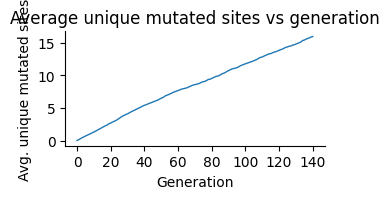

In [181]:
# Global average across all GC cells per generation
def avg_unique_mutations_per_generation(uniq_counts_hist):
    import numpy as np
    return np.array([uc.mean() if uc.size else 0.0 for uc in uniq_counts_hist], dtype=float)
def avg_unique_mutations_in_subtree(uniq_counts_hist, node_indices):
    import numpy as np
    return np.array([
        uniq_counts_hist[t][node_indices[t]].mean() if len(node_indices[t]) else 0.0
        for t in range(len(node_indices))
    ], dtype=float)
def plot_avg_unique_mutations(avg_vals, title=None, figsize=(3.375, 2.1)):
    import numpy as np, matplotlib.pyplot as plt
    T = len(avg_vals) - 1
    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(np.arange(T+1), avg_vals, lw=1.0)
    ax.set_xlabel("Generation")
    ax.set_ylabel("Avg. unique mutated sites")
    ax.set_xticks(np.arange(0, T+1, 20))
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    ax.grid(False)
    if title:
        ax.set_title(title, pad=6)
    plt.tight_layout()
    return fig, ax

# Average across all GC cells
avg_all = avg_unique_mutations_per_generation(uniq_counts_hist)
plot_avg_unique_mutations(avg_all, title="Average unique mutated sites vs generation")




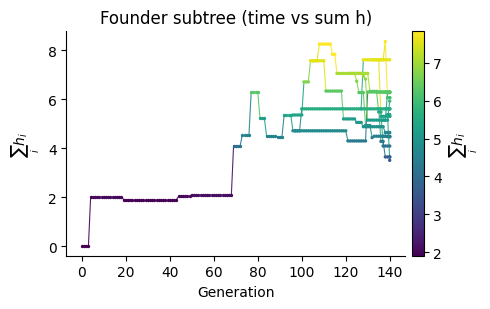

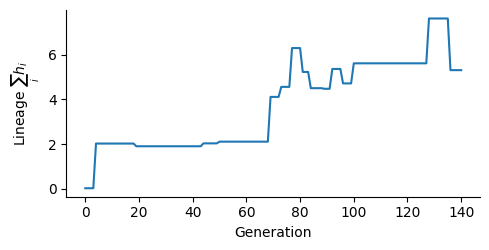

In [182]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Validation & ancestry
# =========================

def validate_tree(history, parent_links):
    T = len(history) - 1
    if T < 1:
        raise ValueError("Need at least two generations 0..T.")
    if len(parent_links) != len(history):
        raise ValueError("parent_links must have same length as history.")
    for t in range(1, T+1):
        if parent_links[t].shape[0] != history[t].shape[0]:
            raise ValueError(f"parent_links[{t}] length must match history[{t}] rows.")
        n_prev = history[t-1].shape[0]
        p = parent_links[t]
        if p.size and ((p < 0).any() or (p >= n_prev).any()):
            raise ValueError(f"parent_links[{t}] has invalid indices.")
    return T

def ancestry_path(parent_links, final_row_T):
    """Row index of the cell at each generation on the chosen lineage."""
    T = len(parent_links) - 1
    path = [None]*(T+1)
    path[T] = int(final_row_T)
    for t in range(T, 0, -1):
        path[t-1] = int(parent_links[t][path[t]])
    return path  # list of ints, len T+1

# =========================
# Subtree construction
# =========================

def build_subtree_from_founder(parent_links, founder_row0):
    """
    Collect all descendants of the founder (gen 0, row founder_row0) down to T.
    Returns:
      node_indices[t]: absolute row indices in history[t] belonging to the subtree.
    """
    T = len(parent_links) - 1
    node_indices = [np.array([], dtype=int) for _ in range(T+1)]
    node_indices[0] = np.array([int(founder_row0)], dtype=int)

    for t in range(1, T+1):
        parents_t = parent_links[t]  # parent row in gen t-1 for each node in gen t
        if node_indices[t-1].size:
            mask = np.isin(parents_t, node_indices[t-1])
            node_indices[t] = np.flatnonzero(mask).astype(int)
        else:
            node_indices[t] = np.array([], dtype=int)
    return node_indices

def prune_subtree_to_reach_T(parent_links, node_indices):
    """
    Prune away branches that don't lead to any node at generation T.
    Keeps only nodes that have a path to gen T (the 'last step').
    """
    T = len(node_indices) - 1
    if node_indices[T].size == 0:
        # nothing reaches T; return empty
        return [np.array([], dtype=int) for _ in range(T+1)]

    # Build quick child lookup (by absolute row ids)
    # children_rows[t][row_parent] = list of child rows in gen t+1
    children_rows = [dict() for _ in range(T)]
    for t in range(T):
        parents_next = parent_links[t+1]
        rows_t = set(int(r) for r in node_indices[t])
        rows_tp1 = node_indices[t+1]
        # initialize dict for nodes present at t
        for r in rows_t:
            children_rows[t][r] = []
        # populate edges restricted to current subtree
        for row_child in rows_tp1:
            p = int(parents_next[row_child])
            if p in children_rows[t]:
                children_rows[t][p].append(int(row_child))

    # Backward keep-sets
    keep = [set() for _ in range(T+1)]
    keep[T] = set(int(r) for r in node_indices[T])  # everything at T is kept

    for t in range(T-1, -1, -1):
        for r in node_indices[t]:
            r_int = int(r)
            # keep parent if any child is kept at next layer
            if any((c in keep[t+1]) for c in children_rows[t].get(r_int, [])):
                keep[t].add(r_int)

    # Filter node_indices
    pruned = [np.array(sorted(list(keep[t])), dtype=int) for t in range(T+1)]
    return pruned

# =========================
# Plot: time vs sum(h) with links
# =========================

def plot_subtree_time_vs_sum(history, parent_links, node_indices,
                             title=None, figsize=(5.0, 3.2),
                             marker_size=2, line_width=0.8):
    """
    x-axis: generation (time)
    y-axis: sum_i h_i
    Points: colored by sum_i h_i
    Edges: parent -> child links, using the parent's color
    """
    import numpy as np
    import matplotlib.pyplot as plt

    T = len(node_indices) - 1

    # --- Precompute sums per node in subtree ---
    sums = []
    for t, inds in enumerate(node_indices):
        if inds.size:
            sums.append(np.sum(history[t][inds], axis=1).astype(float))
        else:
            sums.append(np.array([], dtype=float))

    # --- Global color scaling (robust) ---
    cmap = plt.get_cmap()
    if any(v.size for v in sums):
        all_vals = np.concatenate([v for v in sums if v.size])
        if all_vals.size > 1:
            vmin = float(np.percentile(all_vals, 2.0))
            vmax = float(np.percentile(all_vals, 98.0))
            if vmax <= vmin:
                vmax = vmin + 1e-9
        else:
            vmin = vmax = float(all_vals[0])
    else:
        vmin = vmax = 0.0

    def to_color(val):
        """Map scalar -> RGBA using global vmin/vmax."""
        if vmax > vmin:
            frac = (val - vmin) / (vmax - vmin)
        else:
            frac = 0.5
        return cmap(frac)

    # --- Map row id -> rank within layer (for fast lookup) ---
    ranks = []
    for t, inds in enumerate(node_indices):
        ranks.append({int(r): k for k, r in enumerate(inds)})

    # --- Build edges (with parent's color) ---
    edges = []
    edge_colors = []
    for t in range(T):  # edges from t -> t+1
        if node_indices[t].size == 0 or node_indices[t+1].size == 0:
            continue
        parents_next = parent_links[t+1]
        for k_child, row_child in enumerate(node_indices[t+1]):
            p_row = int(parents_next[row_child])
            if p_row in ranks[t]:
                k_parent = ranks[t][p_row]
                x0, y0 = t,   float(sums[t][k_parent])
                x1, y1 = t+1, float(sums[t+1][k_child])
                edges.append(((x0, y0), (x1, y1)))
                edge_colors.append(to_color(y0))  # parent's color

    # --- Plot ---
    fig, ax = plt.subplots(figsize=figsize)

    # edges first (colored by parent)
    for ((x0, y0), (x1, y1)), col in zip(edges, edge_colors):
        ax.plot([x0, x1], [y0, y1], lw=line_width, alpha=0.9, color=col)

    # nodes (colored by their own sum_i h_i)
    last_scatter = None
    for t in range(T+1):
        if node_indices[t].size:
            xs = np.full(node_indices[t].size, t, dtype=float)
            last_scatter = ax.scatter(xs, sums[t], s=marker_size, zorder=3,
                                      c=sums[t], cmap=cmap, vmin=vmin, vmax=vmax)

    # aesthetics
    ax.set_xlabel("Generation")
    ax.set_ylabel(r"$\sum_i h_i$")
    # tick every 20 generations
    if T >= 0:
        ax.set_xticks(np.arange(0, T+1, 20 if T >= 20 else max(1, T)))
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    ax.grid(False)
    if title:
        ax.set_title(title, pad=6)

    # optional colorbar if we drew points
    if last_scatter is not None:
        cb = fig.colorbar(last_scatter, ax=ax, fraction=0.05, pad=0.02)
        cb.set_label(r"$\sum_i h_i$", rotation=90)

    plt.tight_layout()
    return fig, ax


# =========================
# Driver
# =========================

def plot_founder_subtree_for_final_cell(history, parent_links, final_row_T,
                                        require_reach_T=True,
                                        show_lineage_plot=False,
                                        title_subtree="Founder subtree (time vs sum h)"):
    """
    1) Validate and get ancestry of a chosen final cell.
    2) Use its founder at gen 0 as the subtree root.
    3) Build full descendant subtree; optionally prune branches that don't reach T.
    4) Plot subtree with time on x and sum(h) on y, with links.
    """
    T = validate_tree(history, parent_links)
    path = ancestry_path(parent_links, final_row_T)  # rows at 0..T for this lineage
    founder_row0 = path[0]

    # full subtree from founder
    nodes = build_subtree_from_founder(parent_links, founder_row0)

    # prune to branches that reach T if requested
    if require_reach_T:
        nodes = prune_subtree_to_reach_T(parent_links, nodes)

    fig_sub, ax_sub = plot_subtree_time_vs_sum(
        history, parent_links, nodes, title=title_subtree
    )

    fig_lin, ax_lin = None, None
    if show_lineage_plot:
        traj = np.vstack([history[t][path[t]] for t in range(T+1)])
        y = traj.sum(axis=1)
        fig_lin, ax_lin = plt.subplots(figsize=(5.0, 2.6))
        ax_lin.plot(np.arange(T+1), y, lw=1.5)
        ax_lin.set_xlabel("Generation")
        ax_lin.set_ylabel(r"Lineage $\sum_i h_i$")
        for spine in ["top", "right"]:
            ax_lin.spines[spine].set_visible(False)
        ax_lin.grid(False)
        plt.tight_layout()

    return {
        "path_rows": path,
        "subtree_node_indices": nodes,
        "fig_subtree": fig_sub,
        "ax_subtree": ax_sub,
        "fig_lineage": fig_lin,
        "ax_lineage": ax_lin
    }

# -------- Example --------
final_row_T = 7
out = plot_founder_subtree_for_final_cell(history, parent_links, final_row_T,
                                          require_reach_T=True,
                                          show_lineage_plot=True)


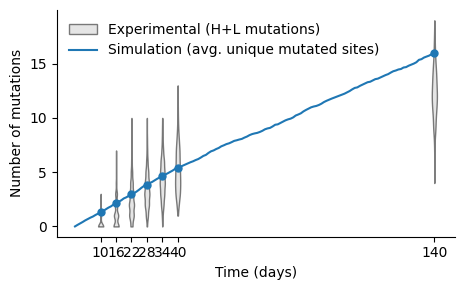

In [183]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --- Load data ---
data_csv_path = "../data_mat/data.csv"
df_mat2 = pd.read_csv(
    data_csv_path,
    keep_default_na=False
)[["time (days)", "mouse", "delta_bind_CGG", "mutations_H", "mutations_L",
   "n_mutations_H", "n_mutations_L"]]
df_mat2["time (days)"] = df_mat2["time (days)"] * 2

# --- Compute combined mutations ---
df_mat2["n_mutations_total"] = df_mat2["n_mutations_H"] + df_mat2["n_mutations_L"]

# --- Figure ---
fig, ax = plt.subplots(figsize=(4.75, 3.0))

# Unique experimental times (sorted)
times_sorted = np.sort(df_mat2["time (days)"].unique())

# --- Violin plot for experimental data ---
parts = ax.violinplot(
    [df_mat2.loc[df_mat2["time (days)"] == t, "n_mutations_total"] for t in times_sorted],
    positions=times_sorted,
    widths=2.0,
    showmeans=False,
    showmedians=False,
    showextrema=False
)

for pc in parts['bodies']:
    pc.set_facecolor('#cccccc')
    pc.set_edgecolor('black')
    pc.set_alpha(0.5)

violin_patch = Patch(facecolor='#cccccc', edgecolor='black', alpha=0.5,
                     label="Experimental (H+L mutations)")

# --- Simulation overlay ---
# 1) plot value for all T (continuous line, no dots)
#    Assumes avg_all is an array-like with one value per integer time step (day after scaling).
x_sim = np.arange(len(avg_all))
line_sim, = ax.plot(x_sim, avg_all, lw=1.5, color='tab:blue',
                    label="Simulation (avg. unique mutated sites)")

# 2) show simulation *only at experimental times* as markers (no connecting lines)
y_at_exp_times = [avg_all[int(t)] for t in times_sorted]
ax.scatter(times_sorted, y_at_exp_times, s=25, color='tab:blue', zorder=3)

# --- Aesthetics ---
ax.set_xlabel("Time (days)")
ax.set_ylabel("Number of mutations")
ax.set_xticks(times_sorted)
ax.tick_params(axis='both', which='both', direction='out')
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.grid(False)

# Legend
ax.legend(handles=[violin_patch, line_sim], frameon=False)

plt.tight_layout()
plt.show()
